In [ ]:
import os
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
directory = '/content/drive/MyDrive/Monkeypox Skin Image Dataset v6'

Mounted at /content/drive


##Data Exploration

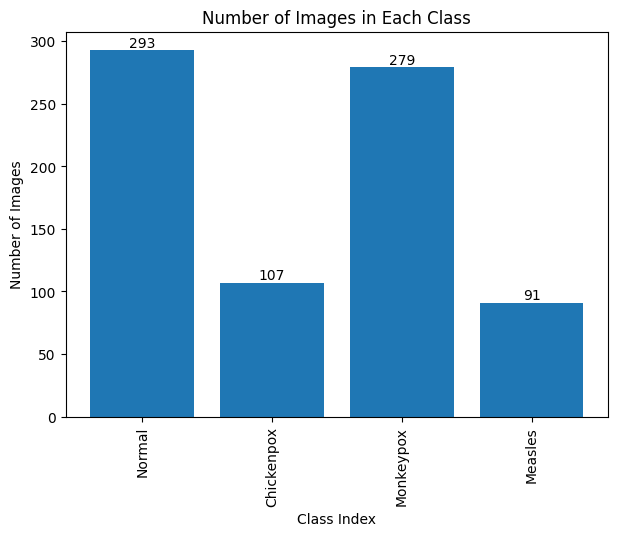

In [ ]:
import os
import matplotlib.pyplot as plt

def plot_dataset():
    class_names = os.listdir(directory)
    new_num_images = []
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        new_num_images.append(len(os.listdir(class_path)))

    plt.figure(figsize=(7, 5))
    plt.bar(range(len(class_names)), new_num_images)
    plt.title('Number of Images in Each Class')
    plt.xlabel('Class Index')
    plt.ylabel('Number of Images')
    plt.xticks(range(len(class_names)), class_names, rotation=90)

    for i, num_images in enumerate(new_num_images):
        plt.text(i, num_images, str(num_images), ha='center', va='bottom')

    plt.show()

plot_dataset()

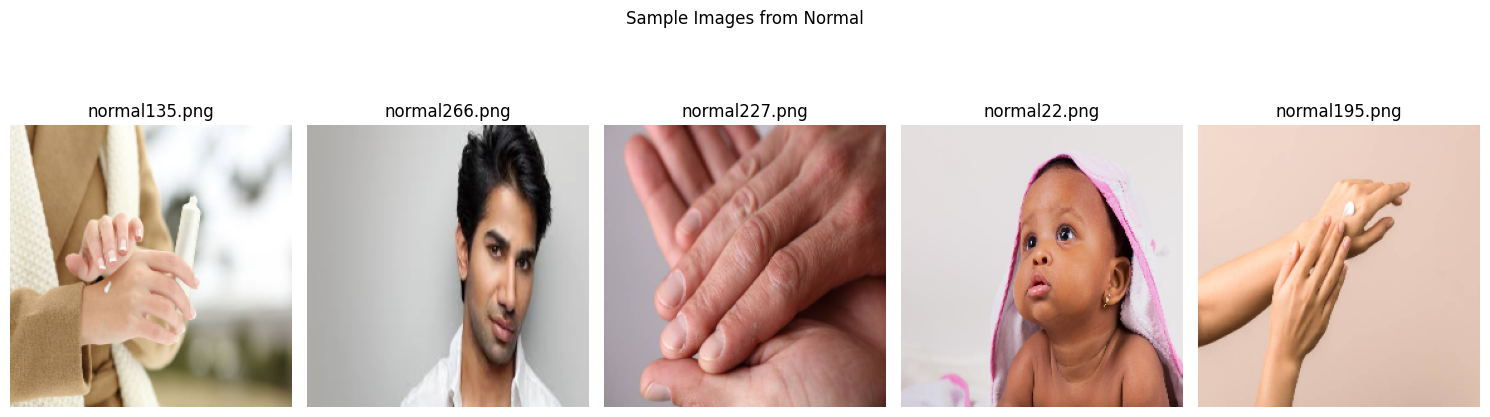

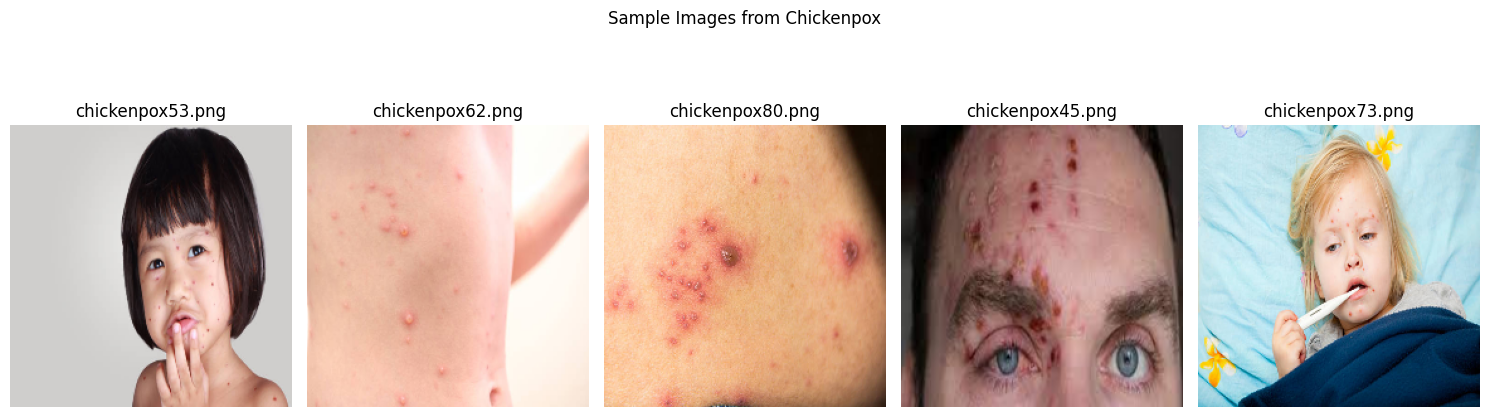

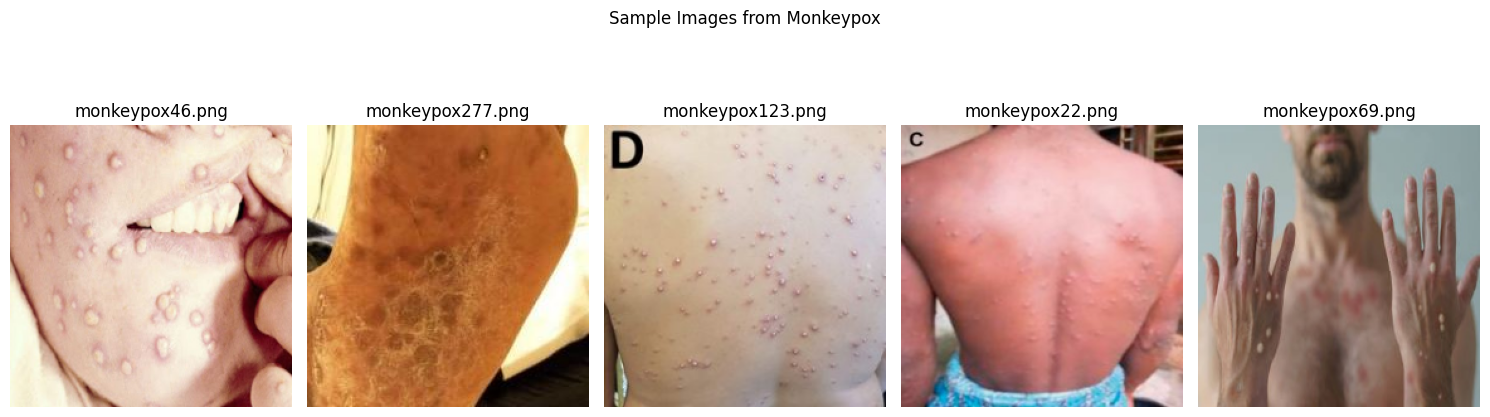

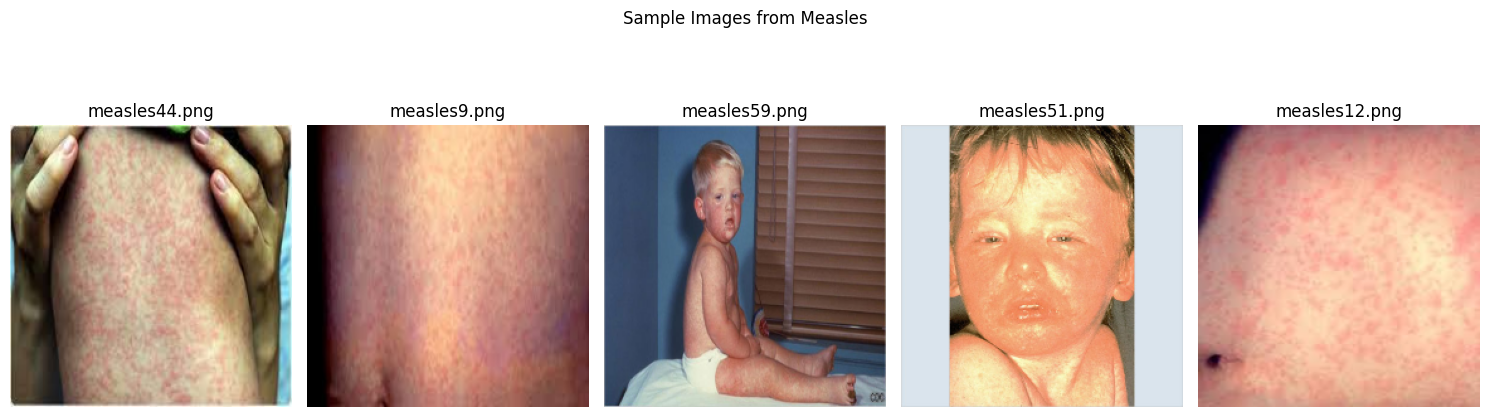

In [ ]:
import random
from PIL import Image, UnidentifiedImageError

def display_images():
    class_names = os.listdir(directory)
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        files = os.listdir(class_path)

        if files:
            sample_files = random.sample(files, min(5, len(files))) #choose 5 images
            plt.figure(figsize=(15,5))
            plt.suptitle(f'Sample Images from {class_name}')

            for i, file in enumerate(sample_files):
                file_path = os.path.join(class_path, file)
                try:
                    img = Image.open(file_path)
                    plt.subplot(1, len(sample_files), i + 1)
                    plt.imshow(img)
                    plt.title(file)
                    plt.axis('off')
                except UnidentifiedImageError:
                    print(f"File {file} not valid, skipped.")
                    continue

            plt.tight_layout()
            plt.show()

display_images()

##Preprocessing

In [ ]:
DATASET_DIR = directory
training_datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2)

train_generator = training_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(224,224),
    class_mode='categorical',
    batch_size=32,
    subset='training')

val_generator = training_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(224,224),
    class_mode='categorical',
    batch_size=32,
    subset='validation')

Found 618 images belonging to 4 classes.
Found 152 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import Xception

pre_trained_model = Xception(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224, 3))

pre_trained_model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1 (Conv2D)     │ (None, 111, 111, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_bn           │ (None, 111, 111, 32)   │            128 │ block1_conv1[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_act          │ (None, 111, 111, 32)   │              0 │ block1_conv1_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2 (Conv2D)     │ (None, 109, 109, 64)   │         18,432 │ block1_conv1_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_bn           │ (None, 109, 109, 64)   │            256 │ block1_conv2[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_act          │ (None, 109, 109, 64)   │              0 │ block1_conv2_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1           │ (None, 109, 109, 128)  │          8,768 │ block1_conv2_act[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1_bn        │ (None, 109, 109, 128)  │            512 │ block2_sepconv1[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_act       │ (None, 109, 109, 128)  │              0 │ block2_sepconv1_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2           │ (None, 109, 109, 128)  │         17,536 │ block2_sepconv2_act[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_bn        │ (None, 109, 109, 128)  │            512 │ block2_sepconv2[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 55, 55, 128)    │          8,192 │ block1_conv2_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_pool               │ (None, 55, 55, 128)    │              0 │ block2_sepconv2_bn[0]… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization  

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 20,806,952 (79.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [ ]:
import numpy as np

x_train_list, y_train_list = [], []

for i in range(len(train_generator)):
    x_train_batch, y_train_batch = train_generator[i]
    x_train_list.append(x_train_batch)
    y_train_list.append(y_train_batch)

x_train = np.concatenate(x_train_list)
y_train = np.concatenate(y_train_list)

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)

x_train shape: (618, 224, 224, 3)
y_train shape: (618, 4)


##K Fold CV

In [ ]:
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=1)

acc_per_fold = []
loss_per_fold = []
val_acc_per_fold = []
val_loss_per_fold = []

fold_no = 1

for train_index, val_index in skf.split(x_train, y_train.argmax(1)):
    print(f'Training for fold {fold_no} ...')

    x_train_fold, x_val_fold = x_train[train_index], x_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    print(f'Number of training samples: {x_train_fold.shape[0]}')
    print(f'Number of validation samples: {x_val_fold.shape[0]}')

    #training
    for layer in pre_trained_model.layers[:-4]:
        layer.trainable = False

    x = pre_trained_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(4, activation='softmax')(x)

    model = Model(
        inputs=pre_trained_model.input,
        outputs=predictions)

    if fold_no == 1:
        model.summary()

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    history = model.fit(
        x_train_fold, y_train_fold,
        epochs=50,
        validation_data=(x_val_fold, y_val_fold),
        verbose=1
    )

    scores = model.evaluate(x_val_fold, y_val_fold, verbose=0)
    print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]}')

    acc_per_fold.append(scores[1])
    loss_per_fold.append(scores[0])
    val_acc_per_fold.append(history.history['val_accuracy'])
    val_loss_per_fold.append(history.history['val_loss'])

    fold_no += 1

Training for fold 1 ...
Number of training samples: 494
Number of validation samples: 124


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1 (Conv2D)     │ (None, 111, 111, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_bn           │ (None, 111, 111, 32)   │            128 │ block1_conv1[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_act          │ (None, 111, 111, 32)   │              0 │ block1_conv1_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2 (Conv2D)     │ (None, 109, 109, 64)   │         18,432 │ block1_conv1_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_bn           │ (None, 109, 109, 64)   │            256 │ block1_conv2[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_act          │ (None, 109, 109, 64)   │              0 │ block1_conv2_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1           │ (None, 109, 109, 128)  │          8,768 │ block1_conv2_act[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1_bn        │ (None, 109, 109, 128)  │            512 │ block2_sepconv1[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_act       │ (None, 109, 109, 128)  │              0 │ block2_sepconv1_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2           │ (None, 109, 109, 128)  │         17,536 │ block2_sepconv2_act[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_bn        │ (None, 109, 109, 128)  │            512 │ block2_sepconv2[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 55, 55, 128)    │          8,192 │ block1_conv2_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_pool               │ (None, 55, 55, 128)    │              0 │ block2_sepconv2_bn[0]… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization  

 Total params: 23,486,508 (89.59 MB)

 Trainable params: 5,788,676 (22.08 MB)

 Non-trainable params: 17,697,832 (67.51 MB)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5693 - loss: 1.0144 - val_accuracy: 0.7500 - val_loss: 0.7311
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.8744 - loss: 0.3718 - val_accuracy: 0.7419 - val_loss: 0.8346
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.9485 - loss: 0.1757 - val_accuracy: 0.7661 - val_loss: 0.9784
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.9691 - loss: 0.0764 - val_accuracy: 0.7823 - val_loss: 1.2393
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.9933 - loss: 0.0241 - val_accuracy: 0.7661 - val_loss: 1.1009
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.9871 - loss: 0.0319 - val_accuracy: 0.8226 - val_loss: 1.2648
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.9836 - loss: 0.0385 - val_accuracy: 0.8065 - val_loss: 1.3948
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.9879 - loss: 0.0305 - val_accuracy: 0.79

In [ ]:
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(acc_per_fold)):
    print('------------------------------------------------------------------------')
    print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {acc_per_fold[i]}%')
print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(acc_per_fold)} (+- {np.std(acc_per_fold)})')
print(f'> Loss: {np.mean(loss_per_fold)}')

for i, val_acc in enumerate(val_acc_per_fold):
    print(f'Validation accuracy for fold {i+1}: {val_acc * 100}%')
print('------------------------------------------------------------------------')

------------------------------------------------------------------------
Score per fold
------------------------------------------------------------------------
> Fold 1 - Loss: 2.6100199222564697 - Accuracy: 0.7661290168762207%
------------------------------------------------------------------------
> Fold 2 - Loss: 0.4534951150417328 - Accuracy: 0.9677419066429138%
------------------------------------------------------------------------
> Fold 3 - Loss: 0.28097206354141235 - Accuracy: 0.9838709831237793%
------------------------------------------------------------------------
> Fold 4 - Loss: 0.18122178316116333 - Accuracy: 0.9837398529052734%
------------------------------------------------------------------------
> Fold 5 - Loss: 0.017306005582213402 - Accuracy: 0.9918699264526367%
------------------------------------------------------------------------
Average scores for all folds:
> Accuracy: 0.9386703372001648 (+- 0.08662588447275005)
> Loss: 0.7086029779165983
Validation accura

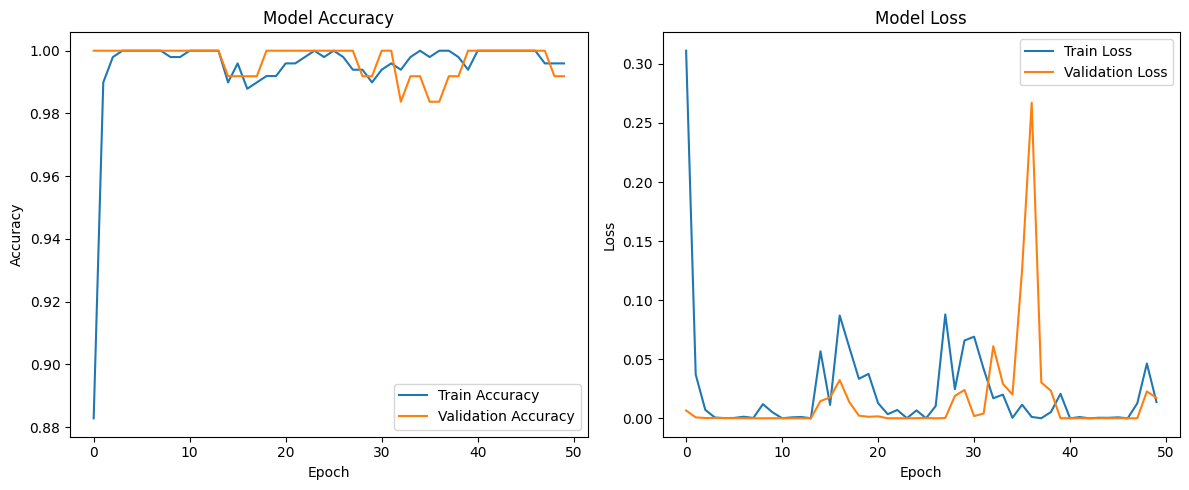

In [ ]:
# Plot akurasi dan loss
plt.figure(figsize=(12, 5))

# Plot akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Shape of x_val: (152, 224, 224, 3)
Shape of y_val: (152, 4)
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
Predicted Classes:  [2 3 3 3 1 2 0 2 3 3 1 3 2 2 0 3 3 2 2 3 1 3 3 3 2 3 2 0 2 2 2 2 2 2 2 2 2
 2 2 3 0 0 3 2 3 2 3 2 2 3 2 2 2 2 3 3 0 0 2 2 3 3 0 3 3 2 2 3 2 3 3 0 1 3
 3 3 2 3 3 2 2 2 3 3 2 3 3 3 3 3 3 3 0 0 2 3 3 2 3 3 3 0 2 1 1 2 1 1 2 3 1
 2 2 2 0 0 2 0 3 3 3 2 3 2 3 3 2 0 3 3 2 0 2 3 3 3 2 2 2 3 3 2 3 0 1 2 2 1
 3 2 2 3]
True Classes:  [0 3 2 3 1 0 0 2 3 1 1 3 2 0 1 3 3 2 2 3 1 3 3 3 2 3 2 0 2 2 2 2 2 2 2 2 1
 0 2 3 0 0 3 2 0 2 2 2 2 3 2 2 3 2 3 3 0 3 2 2 3 3 1 3 3 2 2 3 2 3 3 0 3 3
 3 1 2 3 3 2 1 2 3 3 2 3 1 3 3 1 0 3 0 0 2 2 3 2 3 3 3 0 2 3 1 2 1 1 2 3 1
 2 2 2 0 2 2 0 3 3 3 2 3 2 3 3 2 0 3 3 2 0 0 3 3 3 2 0 2 1 3 2 3 3 1 2 2 1
 3 2 2 3]


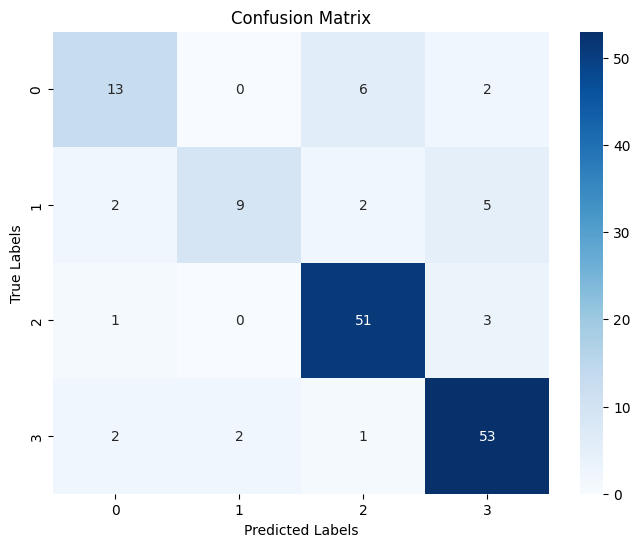

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.62      0.67        21
           1       0.82      0.50      0.62        18
           2       0.85      0.93      0.89        55
           3       0.84      0.91      0.88        58

    accuracy                           0.83       152
   macro avg       0.81      0.74      0.76       152
weighted avg       0.83      0.83      0.82       152



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

x_val_list = []
y_val_list = []

for i in range(len(val_generator)):
    x_val_batch, y_val_batch = val_generator[i]
    x_val_list.append(x_val_batch)
    y_val_list.append(y_val_batch)

x_val = np.concatenate(x_val_list)
y_val = np.concatenate(y_val_list)

print("Shape of x_val:", x_val.shape)
print("Shape of y_val:", y_val.shape)

y_val_pred = model.predict(x_val)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)
y_val_true_classes = np.argmax(y_val, axis=1)

print("Predicted Classes: ", y_val_pred_classes)
print("True Classes: ", y_val_true_classes)

conf_matrix = confusion_matrix(y_val_true_classes, y_val_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(4), yticklabels=range(4))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n", classification_report(y_val_true_classes, y_val_pred_classes))

In [ ]:
model.save("model-mobilenetv2.h5")